In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mean-field theory of equilibrium swelling of polymer networks

and the corresponding affine elastic constants.

In [2]:
from matscipy.calculators.hydrogel.reference_solutions.mean_field_lattices import CROSSLINK_VOLUMES, MeanFieldHydrogelLattice

In [3]:
N = 100 # Number of monomers per chain 
χ =-1 
kuhn =1 

In [4]:
ana = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = χ, )

In [5]:
ana.compute_equilibrium_distance()

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/reference_solutions/mean_field_lattices.py:232: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(self.total_energy, bounds=(0.1 * self.min_radius, 0.9 * self.kuhn * self.chain_nb_monomers), method='bounded', tol=tol)


np.float64(16.898838410236188)

In [6]:
chi = np.linspace(-1.0, 1.5, 100)
reqs = []
energies = []
c44 = []
c11 = []
c12 = []

bulk_modulus = []
shear_modulus = []
youngs_modulus = []
poisson_ratio = []

for c in chi:
    ana = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = c, dim=2)
    req = ana.compute_equilibrium_distance()
    reqs.append(req)
    energies.append(ana.total_energy(r=req))
    c44.append(ana.C44(r=req))
    c11.append(ana.C11(r=req))
    c12.append(ana.C12(r=req))

    bulk_modulus.append(ana.bulk_modulus(r=req))
    shear_modulus.append(ana.shear_modulus(r=req))
    youngs_modulus.append(ana.youngs_modulus(r=req))
    poisson_ratio.append(ana.poisson_ratio(r=req))




energies = np.array(energies)
reqs = np.array(reqs)
c44 = np.array(c44)
c11 = np.array(c11)
c12 = np.array(c12)

poisson_ratio = np.array(poisson_ratio)
youngs_modulus = np.array(youngs_modulus)
shear_modulus = np.array(shear_modulus)     
bulk_modulus = np.array(bulk_modulus)


/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:279: UserWarning: Volume fraction φ was clipped: original range [1.33e+00, 1.33e+00] to valid range [1e-10, 0.9999999999]. This may indicate unphysical crosslink densities.
  warnings.warn(f"Volume fraction φ was clipped: original range [{np.min(ϕ_original):.2e}, {np.max(ϕ_original):.2e}] "
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:295: RuntimeWarning: invalid value encountered in log
  + 1 / v0 * (1 - ϕ) * np.log(1 - ϕ)
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:279: UserWarning: Volume fraction φ was clipped: original range [2.21e+00, 2.21e+00] to valid range [1e-10, 0.9999999999]. This may indicate unphysical crosslink densities.
  warnings.warn(f"Volume fraction φ was clipped: original range [{np.min(ϕ_original):.2e}, {np.max(

Text(0.5, 0, 'Flory parameter $\\chi$')

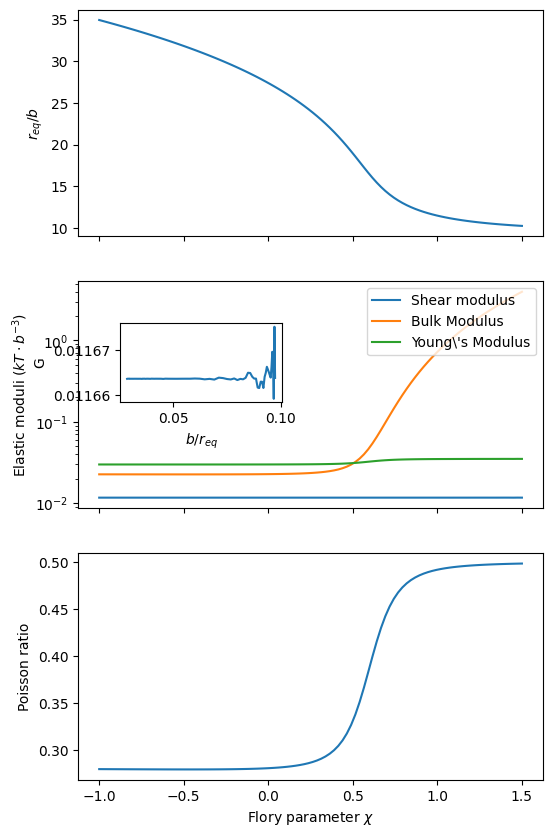

In [7]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 10))
ax = axes[0]

ax.plot(chi, reqs)

# ax.set_xlabel('Flory parameter $\chi$')
ax.set_ylabel('$r_{eq} / b$')

ax = axes[1]
ax.plot(chi, shear_modulus, label=r'Shear modulus')
ax.plot(chi, bulk_modulus, label=r'Bulk Modulus')
ax.plot(chi, youngs_modulus, label=r'Young\'s Modulus')
ax.legend(loc='upper right')

ax.set_ylabel('Elastic moduli $(kT \cdot b^{-3})$')

# ax.set_ylim(top=0.)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(
    ax,
    width="35%",   # relative to parent axis
    height="35%",
    loc="upper left",
    borderpad=3.0
)

ax.set_yscale('log')
# Example content
axins.plot(1/reqs, c44, label=r'Shear modulus')
axins.set_ylabel('G')
axins.set_xlabel(r'$b / r_{eq}$')

ax = axes[2]
ax.plot(chi, poisson_ratio, label=r'Poisson ratio')
ax.set_ylabel('Poisson ratio')

ax.set_xlabel('Flory parameter $\chi$')


## MatscipyCalculator and ShellCalculator

### Matscipy calculator

In [8]:
from matscipy.calculators.hydrogel.snippets.factory import create_graphite_lattice

In [38]:

# Derived parameters
from matscipy.calculators.hydrogel.calculator import Hydrogel
from matscipy.calculators.hydrogel.potentials import GaussianChain



In [39]:
def create_graphite_hydrogel(flory_chi,rc_factor=None, rc=None, n_cells=2):
    mf = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = flory_chi, dim=2)
    req_mf = mf.compute_equilibrium_distance()
    atoms, molecules = create_graphite_lattice(crosslink_spacing=req_mf, n_cells=n_cells)
    calc = Hydrogel(
        cutoff=rc if rc is not None else rc_factor * req_mf,
        chain_monomers=N,
        kuhn_length=kuhn,
        monomer_volume=mf.v0,
        flory_chi=flory_chi ,
        coordination=mf.coordination,
        molecules=molecules,
        chain=GaussianChain(
            kuhn_length=kuhn,
            chain_monomers=N,
            dim=2,
        ),
        dim=2,
    )
    atoms.calc = calc
    return atoms, molecules, mf

Utilities to extract the desired elastic properties

In [40]:
from matscipy.elasticity import fit_elastic_constants
from ase.optimize import FIRE
from ase.constraints import UnitCellFilter

from matscipy.elasticity import Voigt_6_to_full_3x3_strain


def compute_nonaffine_displacements(atoms, gam = 1e-2):
    
    at = atoms.copy()
    at.calc = atoms.calc
    
    strain = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0]) * gam  # Small uniaxial strain in x-direction
    T = np.eye(3) + Voigt_6_to_full_3x3_strain(strain)
    at.set_cell(np.dot(T, at.cell.T).T, scale_atoms=True)

    positions_sheared_affine = at.positions.copy()
    FIRE(at).run(fmax=1e-6)
    positions_sheared_relaxed = at.positions.copy()

    nonaffine_displacements = positions_sheared_relaxed - positions_sheared_affine
    nonaffine_displacements_squared = np.mean(np.sum(nonaffine_displacements**2, axis=1)) / gam**2
    return nonaffine_displacements_squared

In [41]:
from visualization import show_atoms_with_bonds
atoms, molecules, mf = create_graphite_hydrogel(χ, rc_factor =3, n_cells=2)
show_atoms_with_bonds(atoms, molecules)

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/reference_solutions/mean_field_lattices.py:232: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(self.total_energy, bounds=(0.1 * self.min_radius, 0.9 * self.kuhn * self.chain_nb_monomers), method='bounded', tol=tol)
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:279: UserWarning: Volume fraction φ was clipped: original range [1.12e+00, 1.12e+00] to valid range [1e-10, 0.9999999999]. This may indicate unphysical crosslink densities.
  warnings.warn(f"Volume fraction φ was clipped: original range [{np.min(ϕ_original):.2e}, {np.max(ϕ_original):.2e}] "
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:295: RuntimeWarning: invalid value encountered in log
  + 1 / v0 * (1 - ϕ) *

NGLWidget()

## Convergence to the mean-field theory with increasing cutoff

In [42]:
flory_chi = 0

### Shell calculator

In [43]:
from matscipy.calculators.hydrogel.reference_solutions.lattice_shell_structures import GraphiteShellStructure


shellstructure = GraphiteShellStructure(cutoff=10.0)

In [44]:
from matscipy.calculators.hydrogel.reference_solutions.shell_calculator import ShellHydrogelCalculator
from matscipy.calculators.hydrogel.potentials import FloryHuggins, LucyWeightFunction2D

mf = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = flory_chi, dim=2)
req_mf = mf.compute_equilibrium_distance()

def create_shellcalc(rc_factor):
    return ShellHydrogelCalculator(shellstructure, 
        chain_potential=GaussianChain(1, mf.chain_nb_monomers, dim=2),
        embedding_potential=FloryHuggins(
            mf.chain_nb_monomers,
            monomer_volume=mf.v0,
            flory_chi=mf.flory_chi,
            coordination = mf.coordination,
        ),
        weight_function=LucyWeightFunction2D(cutoff=rc_factor * req_mf),)



In [78]:



rc_factors = np.linspace(1.2, 5, 200)
Re = np.sqrt(N) * kuhn  # RMS end-to-end distance of a free chain


C11a = []
C12a = []
C44a = []   
C11na = []
C12na = []
C44na = []
reqs_mf = []
reqs_sim = []
nonaffine_disp = []

for rc_factor in rc_factors:


    atoms, molecules, ana = create_graphite_hydrogel(flory_chi, rc_factor=rc_factor, n_cells=2)
    req_mf = ana.compute_equilibrium_distance()


    # Relax to equilibrium
    ucf = UnitCellFilter(atoms, hydrostatic_strain=True)
    opt = FIRE(ucf)
    opt.run(fmax=1e-3)

    reqs_sim.append(np.mean(molecules.get_distances(atoms)))

    Ca, C_err = fit_elastic_constants(
            atoms,
            symmetry="triclinic",
            N_steps=5,
            delta=1e-4,
            optimizer=None, # So we are computing the affine elastic constants
            fmax=1e-6,
            verbose=True,
            )

    C11a.append(Ca[0,0])
    C12a.append(Ca[0,1])
    C44a.append(Ca[5,5])

    Cna, C_err = fit_elastic_constants(
            atoms,
            symmetry="triclinic",
            N_steps=5,
            delta=1e-4,
            optimizer=FIRE, # So we are computing the nonaffine elastic constants
            fmax=1e-6,
            verbose=True,
            )

    C11na.append(Cna[0,0])
    C12na.append(Cna[0,1])
    C44na.append(Cna[5,5])

    reqs_mf.append(req_mf)

    nonaffine_disp.append(compute_nonaffine_displacements(atoms, gam=1e-2))

    # Cna = nonaffine_elastic_contribution(atoms)
    


      Step     Time          Energy          fmax
FIRE:    0 15:28:58    -1013.015664        3.811347
FIRE:    1 15:28:58    -1013.440075        3.611865
FIRE:    2 15:28:58    -1014.200520        3.215971
FIRE:    3 15:28:58    -1015.134325        2.632264
FIRE:    4 15:28:58    -1015.933483        1.978232
FIRE:    5 15:28:58    -1016.502580        1.304245
FIRE:    6 15:28:58    -1016.834949        0.611707
FIRE:    7 15:28:58    -1016.924398        0.098023
FIRE:    8 15:28:58    -1016.924470        0.096500
FIRE:    9 15:28:58    -1016.924608        0.093477
FIRE:   10 15:28:58    -1016.924805        0.089001
FIRE:   11 15:28:58    -1016.925049        0.083144
FIRE:   12 15:28:58    -1016.925323        0.075996
FIRE:   13 15:28:58    -1016.925612        0.067670
FIRE:   14 15:28:58    -1016.925897        0.058295
FIRE:   15 15:28:58    -1016.926187        0.046892
FIRE:   16 15:28:58    -1016.926451        0.033287
FIRE:   17 15:28:58    -1016.926645        0.017415
FIRE:   18 15:

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/reference_solutions/mean_field_lattices.py:232: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(self.total_energy, bounds=(0.1 * self.min_radius, 0.9 * self.kuhn * self.chain_nb_monomers), method='bounded', tol=tol)
/tmp/ipykernel_788777/291461272.py:23: FutureWarning: Import UnitCellFilter from ase.filters
  ucf = UnitCellFilter(atoms, hydrostatic_strain=True)


Fitting C_11
Strain array([-2.e-04, -1.e-04,  0.e+00,  1.e-04,  2.e-04])
Stress array([-0.00181346, -0.00081672,  0.00018001,  0.0011767 ,  0.00217337]) GPa
Cij (gradient) / GPa    :     9.967080625849672
Error in Cij / GPa      :     9.071444690833956e-05
Correlation coefficient :     0.9999999998757466
Setting C11 (1) to 0.062210 +/- 0.000001


Fitting C_21
Strain array([-2.e-04, -1.e-04,  0.e+00,  1.e-04,  2.e-04])
Stress array([-0.00049352, -0.00015668,  0.00018001,  0.00051655,  0.00085295]) GPa
Cij (gradient) / GPa    :     3.3661703844766415
Error in Cij / GPa      :     0.000495614665481531
Correlation coefficient :     0.9999999674832339
Setting C21 (7) to 0.021010 +/- 0.000003


Fitting C_31
Strain array([-2.e-04, -1.e-04,  0.e+00,  1.e-04,  2.e-04])
Stress array([0., 0., 0., 0., 0.]) GPa
Cij (gradient) / GPa    :     0.0
Error in Cij / GPa      :     0.0
Correlation coefficient :     0.0      <----- WARNING
Setting C31 (8) to 0.000000 +/- 0.000000


Fitting C_41
Strain array

In [79]:
C11a = np.array(C11a)
C12a = np.array(C12a)
C44a = np.array(C44a)   
C11na = np.array(C11na)
C12na = np.array(C12na)
C44na = np.array(C44na)
reqs_mf = np.array(reqs_mf)
reqs_sim = np.array(reqs_sim)

nonaffine_disp = np.array(nonaffine_disp)

In [80]:
C44a

array([0.02059982, 0.01963431, 0.01872971, 0.01788097, 0.01708344,
       0.01633467, 0.01562826, 0.01496338, 0.01433502, 0.01374252,
       0.01318379, 0.01265409, 0.01215145, 0.01167779, 0.01122688,
       0.01079837, 0.01039244, 0.0100067 , 0.00963918, 0.00929039,
       0.00895958, 0.00864185, 0.0110037 , 0.01280999, 0.01407727,
       0.01499712, 0.01565809, 0.01613001, 0.01645957, 0.01667077,
       0.01679509, 0.01684281, 0.01682812, 0.0167666 , 0.01666505,
       0.01653007, 0.01636784, 0.01618396, 0.01642485, 0.01661148,
       0.01672336, 0.01677449, 0.01677521, 0.01673394, 0.01665761,
       0.01655193, 0.01642171, 0.016271  , 0.01610304, 0.01592108,
       0.01572762, 0.01552481, 0.01531431, 0.01509773, 0.01487647,
       0.01465174, 0.01442455, 0.01419582, 0.01396645, 0.01373677,
       0.01350734, 0.01327907, 0.01305212, 0.01282703, 0.01260407,
       0.01238345, 0.01216534, 0.01194895, 0.01173629, 0.01152645,
       0.01131987, 0.01111641, 0.01091737, 0.01072036, 0.01052

In [81]:
mf.shear_modulus(req_mf)

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:279: UserWarning: Volume fraction φ was clipped: original range [3.23e+03, 3.23e+03] to valid range [1e-10, 0.9999999999]. This may indicate unphysical crosslink densities.
  warnings.warn(f"Volume fraction φ was clipped: original range [{np.min(ϕ_original):.2e}, {np.max(ϕ_original):.2e}] "
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:295: RuntimeWarning: invalid value encountered in log
  + 1 / v0 * (1 - ϕ) * np.log(1 - ϕ)
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:310: RuntimeWarning: invalid value encountered in log
  - 1 / v0 * (np.log(1 - ϕ) + 1)


np.float64(nan)

(1.0, 5.0)

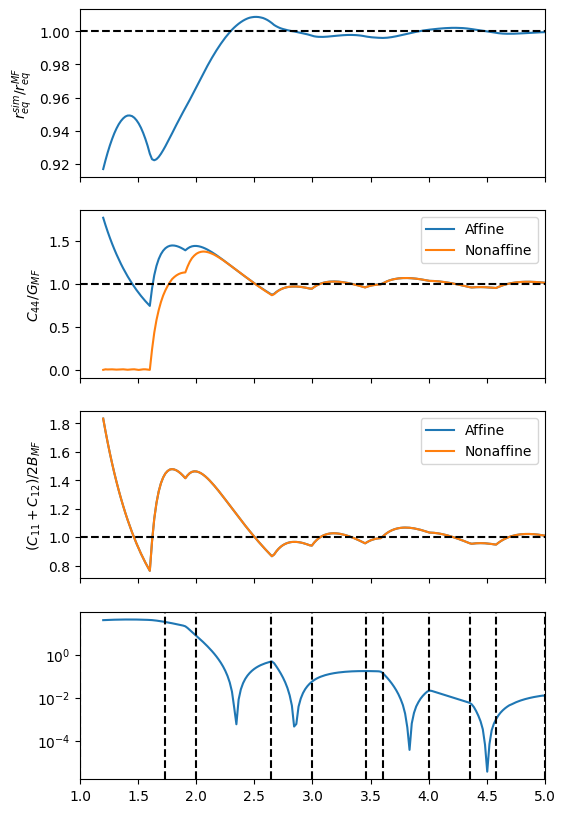

In [82]:
fig, axes= plt.subplots(4, 1, sharex=True, figsize=(6, 10))
ax = axes[0]    

ax.plot(rc_factors, reqs_sim / req_mf, label='Mean-field theory', )
ax.axhline(1, ls="--", c='k')
ax.set_ylabel('$r_{eq}^{sim} / r_{eq}^{MF}$')

ax = axes[1]    
ax.plot(rc_factors, C44a / mf.shear_modulus(r=req_mf), label='Affine', )
ax.plot(rc_factors, C44na / mf.shear_modulus(r=req_mf), label='Nonaffine', )
ax.legend()

ax.set_ylabel('$C_{44} / G_{MF}$')

ax.axhline(1, ls="--", c='k')

ax = axes[2]    
ax.plot(rc_factors,(C11a + C12a) / 2 / mf.bulk_modulus(r=req_mf), label='Affine', )
ax.plot(rc_factors, (C11na + C12na) / 2 / mf.bulk_modulus(r=req_mf), label='Nonaffine', )
ax.legend()
ax.axhline(1, ls="--", c='k')

ax.set_ylabel('$(C_{11} + C_{12})/2B_{MF}$')
ax = axes[3]


ax.plot(rc_factors, nonaffine_disp, label='Nonaffine displacements', )
ax.set_yscale('log')

for a in shellstructure.a:
    ax.axvline(a, ls='--', c='k')

ax.set_xlim(1,5)

array([ 1.        ,  1.73205081,  2.        ,  2.64575131,  3.        ,
        3.46410162,  3.60555128,  4.        ,  4.35889894,  4.58257569,
        5.        ,  5.19615242,  5.29150262,  5.56776436,  6.        ,
        6.08276253,  6.244998  ,  6.55743852,  6.92820323,  7.        ,
        7.21110255,  7.54983444,  7.81024968,  7.93725393,  8.        ,
        8.18535277,  8.54400375,  8.66025404,  8.71779789,  8.88819442,
        9.        ,  9.16515139,  9.53939201,  9.64365076,  9.8488578 ,
       10.        ])

## Another point of view: Influence of the Flory Huggins parameter on the elastic constants

This time we fix the cutoff to physically reasonable value and vary the Flory Huggins parameter.

Using MatscipyCalculator only (because it allows for nonaffine elastic constants)

In [27]:


flory_parameters = np.linspace(-1., 1, 20)
Re = np.sqrt(N) * kuhn  # RMS end-to-end distance of a free chain
rc = 3* Re


C11a = []
C12a = []
C44a = []   
C11na = []
C12na = []
C44na = []
reqs_mf = []
reqs_sim = []
nonaffine_disp = []

for χ in flory_parameters:


    atoms, molecules, ana = create_graphite_hydrogel(χ, rc=rc, n_cells=2)
    req_mf = ana.compute_equilibrium_distance()


    # Relax to equilibrium
    ucf = UnitCellFilter(atoms, hydrostatic_strain=True)
    opt = FIRE(ucf)
    opt.run(fmax=1e-3)

    reqs_sim.append(np.mean(molecules.get_distances(atoms)))

    Ca, C_err = fit_elastic_constants(
            atoms,
            symmetry="triclinic",
            N_steps=5,
            delta=1e-4,
            optimizer=None, # So we are computing the affine elastic constants
            fmax=1e-6,
            verbose=True,
            )

    C11a.append(Ca[0,0])
    C12a.append(Ca[0,1])
    C44a.append(Ca[5,5])

    Cna, C_err = fit_elastic_constants(
            atoms,
            symmetry="triclinic",
            N_steps=5,
            delta=1e-4,
            optimizer=FIRE, # So we are computing the nonaffine elastic constants
            fmax=1e-6,
            verbose=True,
            )

    C11na.append(Cna[0,0])
    C12na.append(Cna[0,1])
    C44na.append(Cna[5,5])

    reqs_mf.append(req_mf)

    nonaffine_disp.append(compute_nonaffine_displacements(atoms, gam=1e-2))

    # Cna = nonaffine_elastic_contribution(atoms)
    

      Step     Time          Energy          fmax
FIRE:    0 15:00:19    -1886.090104       12.334751
FIRE:    1 15:00:19    -1890.332150       12.156714
FIRE:    2 15:00:19    -1894.512522       11.978677
FIRE:    3 15:00:19    -1898.631221       11.800640
FIRE:    4 15:00:19    -1902.688246       11.622604
FIRE:    5 15:00:19    -1906.683597       11.444567
FIRE:    6 15:00:19    -1910.617274       11.266530
FIRE:    7 15:00:19    -1914.489278       11.088493
FIRE:    8 15:00:19    -1918.299607       10.910456
FIRE:    9 15:00:19    -1922.048264       10.732420
FIRE:   10 15:00:19    -1925.735070       10.546647
FIRE:   11 15:00:19    -1929.321351       10.094002
FIRE:   12 15:00:19    -1932.684710        9.262992
FIRE:   13 15:00:19    -1935.697589        8.073869
FIRE:   14 15:00:19    -1938.239430        6.546807
FIRE:   15 15:00:19    -1940.196646        4.701875
FIRE:   16 15:00:19    -1941.462584        2.559020
FIRE:   17 15:00:19    -1941.937472        0.138038
FIRE:   18 15:

/tmp/ipykernel_788777/537687713.py:24: FutureWarning: Import UnitCellFilter from ase.filters
  ucf = UnitCellFilter(atoms, hydrostatic_strain=True)


Fitting C_11
Strain array([-2.e-04, -1.e-04,  0.e+00,  1.e-04,  2.e-04])
Stress array([-0.00556036, -0.00287877, -0.00019803,  0.00248185,  0.00516089]) GPa
Cij (gradient) / GPa    :     26.80312715293516
Error in Cij / GPa      :     0.002901237864169844
Correlation coefficient :     0.9999999824253377
Setting C11 (1) to 0.167292 +/- 0.000018


Fitting C_21
Strain array([-2.e-04, -1.e-04,  0.e+00,  1.e-04,  2.e-04])
Stress array([-0.00198845, -0.00109292, -0.00019803,  0.00069621,  0.00158982]) GPa
Cij (gradient) / GPa    :     8.945668754579389
Error in Cij / GPa      :     0.0021924060788795635
Correlation coefficient :     0.9999999099035727
Setting C21 (7) to 0.055834 +/- 0.000014


Fitting C_31
Strain array([-2.e-04, -1.e-04,  0.e+00,  1.e-04,  2.e-04])
Stress array([0., 0., 0., 0., 0.]) GPa
Cij (gradient) / GPa    :     0.0
Error in Cij / GPa      :     0.0
Correlation coefficient :     0.0      <----- WARNING
Setting C31 (8) to 0.000000 +/- 0.000000


Fitting C_41
Strain array(

In [28]:
C11a = np.array(C11a)
C12a = np.array(C12a)
C44a = np.array(C44a)   
C11na = np.array(C11na)
C12na = np.array(C12na)
C44na = np.array(C44na)
reqs_mf = np.array(reqs_mf)
reqs_sim = np.array(reqs_sim)

nonaffine_disp = np.array(nonaffine_disp)

In [29]:
shear_modulus_reuss = (C11a - C12a) / 2


In [30]:
reqs_mf = []
energies_mf = []
c44_mf = []
c11_mf = []
c12_mf = []

bulk_modulus_mf = []
shear_modulus_mf = []
youngs_modulus_mf = []
poisson_ratio_mf = []

for c in flory_parameters:
    ana = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = c, dim=2)
    req = ana.compute_equilibrium_distance()
    reqs_mf.append(req)
    energies_mf.append(ana.total_energy(r=req))
    c44_mf.append(ana.C44(r=req))
    c11_mf.append(ana.C11(r=req))
    c12_mf.append(ana.C12(r=req))
    bulk_modulus_mf.append(ana.bulk_modulus(r=req))
    shear_modulus_mf.append(ana.shear_modulus(r=req))
    youngs_modulus_mf.append(ana.youngs_modulus(r=req))
    poisson_ratio_mf.append(ana.poisson_ratio(r=req))




energies_mf = np.array(energies_mf)
reqs_mf = np.array(reqs_mf)
c44_mf = np.array(c44_mf)
c11_mf = np.array(c11_mf)
c12_mf = np.array(c12_mf)

poisson_ratio_mf = np.array(poisson_ratio_mf)
youngs_modulus_mf = np.array(youngs_modulus_mf)
shear_modulus_mf = np.array(shear_modulus_mf)     
bulk_modulus_mf = np.array(bulk_modulus_mf)

Text(0, 0.5, 'non-affine displacement$^2 / \\gamma^2$')

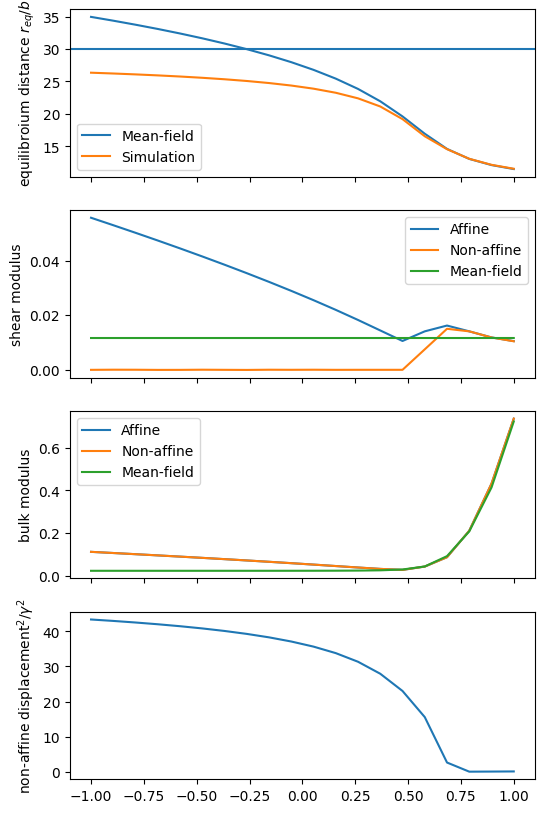

In [31]:
fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

ax= axes[0]
ax.plot(flory_parameters, reqs_mf, label='Mean-field')
ax.plot(flory_parameters, reqs_sim, label='Simulation')
ax.axhline(rc)
ax.legend()

ax.set_ylabel('equilibroium distance $r_{eq} / b$')

ax= axes[1]
ax.plot(flory_parameters, C44a, label='Affine')
ax.plot(flory_parameters, C44na, label='Non-affine')
ax.plot(flory_parameters, shear_modulus_mf, label='Mean-field')

ax.legend()
ax.set_ylabel('shear modulus')

ax= axes[2]
ax.plot(flory_parameters, (C11a + C12a) / 2, label='Affine')
ax.plot(flory_parameters, (C11na + C12na) / 2, label='Non-affine')
ax.plot(flory_parameters, bulk_modulus_mf, label='Mean-field')


ax.set_ylabel('bulk modulus')
ax.legend()

ax= axes[3]

ax.plot(flory_parameters, nonaffine_disp, )
ax.set_ylabel('non-affine displacement$^2 / \gamma^2$')

In [ ]:
χ = 0.5 

atoms, molecules, ana = create_graphite_hydrogel(flory_chi=χ, rc=rc, n_cells=2)

ucf = UnitCellFilter(atoms, hydrostatic_strain=True)
opt = FIRE(ucf)
opt.run(fmax=1e-3)

      Step     Time          Energy          fmax
FIRE:    0 14:29:38     -549.852046        0.332589
FIRE:    1 14:29:38     -549.855332        0.326204
FIRE:    2 14:29:38     -549.861654        0.313540
FIRE:    3 14:29:38     -549.870527        0.294811
FIRE:    4 14:29:38     -549.881269        0.270337
FIRE:    5 14:29:38     -549.893052        0.240538
FIRE:    6 14:29:38     -549.904960        0.205935
FIRE:    7 14:29:38     -549.916063        0.167145
FIRE:    8 14:29:38     -549.926346        0.120268
FIRE:    9 14:29:38     -549.934122        0.064887
FIRE:   10 14:29:38     -549.937294        0.001220
FIRE:   11 14:29:38     -549.933700        0.069455
FIRE:   12 14:29:38     -549.933778        0.068703
FIRE:   13 14:29:38     -549.933928        0.067209
FIRE:   14 14:29:38     -549.934147        0.064988
FIRE:   15 14:29:38     -549.934423        0.062065
FIRE:   16 14:29:38     -549.934745        0.058472
FIRE:   17 14:29:38     -549.935099        0.054250
FIRE:   18 14:

/tmp/ipykernel_746194/2244824135.py:5: FutureWarning: Import UnitCellFilter from ase.filters
  ucf = UnitCellFilter(atoms, hydrostatic_strain=True)


np.True_

      Step     Time          Energy          fmax
FIRE:    0 14:49:32     -549.935604        0.009111
FIRE:    1 14:49:32     -549.935610        0.009093
FIRE:    2 14:49:32     -549.935624        0.009057
FIRE:    3 14:49:32     -549.935643        0.009004
FIRE:    4 14:49:32     -549.935669        0.008932
FIRE:    5 14:49:32     -549.935702        0.008844
FIRE:    6 14:49:32     -549.935740        0.008738
FIRE:    7 14:49:32     -549.935783        0.008614
FIRE:    8 14:49:32     -549.935837        0.008458
FIRE:    9 14:49:32     -549.935904        0.008262
FIRE:   10 14:49:32     -549.935985        0.008017
FIRE:   11 14:49:32     -549.936082        0.007715
FIRE:   12 14:49:32     -549.936196        0.007343
FIRE:   13 14:49:32     -549.936328        0.006888
FIRE:   14 14:49:32     -549.936477        0.006336
FIRE:   15 14:49:32     -549.936639        0.005672
FIRE:   16 14:49:32     -549.936809        0.004880
FIRE:   17 14:49:32     -549.936977        0.003944
FIRE:   18 14:

In [ ]:

naforces_icab = atoms.calc.get_non_affine_contribution_to_elastic_constants(atoms)


NotImplementedError: 

In [ ]:
atoms.calc.get_elastic_constants(atoms)

NotImplementedError: 